# Análisis de sesión — §4 del marco teórico

Lee los 6 CSVs de una sesión (`sessions/<id>/`) y produce las 5 tablas y 5 gráficos
que se citan en el capítulo de Resultados de la tesis.

**Uso**: editar `SESSION_DIR` abajo y ejecutar todas las celdas.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === EDITAR esta línea ===
SESSION_DIR = Path('sessions') / sorted([p.name for p in Path('sessions').glob('*')])[-1] if any(Path('sessions').glob('*')) else None
print('Session dir:', SESSION_DIR)
assert SESSION_DIR and SESSION_DIR.exists(), 'No hay sesión disponible. Corre session.sh start primero.'

def load(name, **kw):
    p = SESSION_DIR / name
    if not p.exists():
        print(f'[warn] {name} no existe')
        return pd.DataFrame()
    df = pd.read_csv(p, **kw)
    print(f'{name}: {len(df)} filas')
    return df

resources = load('resources.csv')
router = load('router.csv')
latency = load('backend_latency.csv')
loadtest = load('loadtest.csv')
events = load('events.csv')
survey = load('survey.csv')

for df in (resources, router, latency, loadtest, events):
    if 'ts' in df.columns:
        df['dt'] = pd.to_datetime(df['ts'], unit='s')

Session dir: sessions/esc1_2026-05-17_1848_validation
resources.csv: 211 filas
[warn] router.csv no existe
backend_latency.csv: 4408 filas
loadtest.csv: 3 filas
events.csv: 6 filas
[warn] survey.csv no existe


## Tabla 1 — Resumen de recursos del Pi

In [2]:
if not resources.empty:
    agg = resources.groupby('source').agg(
        cpu_pct_mean=('cpu_pct', 'mean'),
        cpu_pct_p50=('cpu_pct', lambda x: np.percentile(x, 50)),
        cpu_pct_p95=('cpu_pct', lambda x: np.percentile(x, 95)),
        cpu_pct_max=('cpu_pct', 'max'),
        mem_mb_mean=('mem_mb', 'mean'),
        mem_mb_max=('mem_mb', 'max'),
        net_rx_kbps_mean=('net_rx_kbps', 'mean'),
        net_tx_kbps_mean=('net_tx_kbps', 'mean'),
    ).round(1)
    print('TABLA 1 — Recursos del Pi')
    display(agg)
else:
    print('Sin datos de recursos')

TABLA 1 — Recursos del Pi


,cpu_pct_mean,cpu_pct_p50,cpu_pct_p95,cpu_pct_max,mem_mb_mean,mem_mb_max,net_rx_kbps_mean,net_tx_kbps_mean
source,,,,,,,,
esc1-nodered,25.0,27.0,44.6,53.5,118.3,136.7,0.0,0.0
host,7.3,7.2,11.3,16.1,311.2,321.2,11.7,9.6


## Gráfico 1 — CPU/RAM del Pi vs tiempo

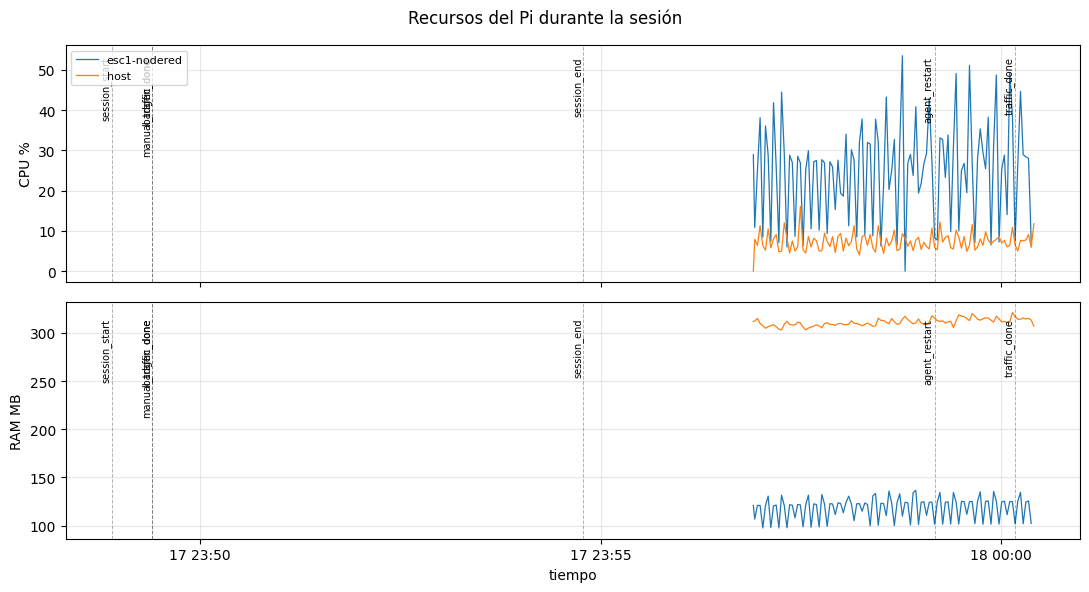

In [3]:
if not resources.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    for src, g in resources.groupby('source'):
        ax1.plot(g['dt'], g['cpu_pct'], label=src, linewidth=0.9)
        ax2.plot(g['dt'], g['mem_mb'], label=src, linewidth=0.9)
    if not events.empty:
        for _, ev in events.iterrows():
            t = pd.to_datetime(ev['ts'], unit='s')
            for ax in (ax1, ax2):
                ax.axvline(t, color='k', alpha=0.3, linestyle='--', linewidth=0.7)
                ax.annotate(ev['event'], xy=(t, ax.get_ylim()[1]*0.95),
                            fontsize=7, rotation=90, ha='right', va='top')
    ax1.set_ylabel('CPU %'); ax1.legend(loc='upper left', fontsize=8); ax1.grid(alpha=0.3)
    ax2.set_ylabel('RAM MB'); ax2.set_xlabel('tiempo'); ax2.grid(alpha=0.3)
    fig.suptitle('Recursos del Pi durante la sesión')
    plt.tight_layout(); plt.show()

## Gráfico 2 — Teléfonos asociados vs CPU del Pi

In [4]:
if not router.empty and not resources.empty:
    host = resources[resources['source'] == 'host'].copy()
    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.plot(host['dt'], host['cpu_pct'], color='tab:red', label='CPU host %', linewidth=0.9)
    ax1.set_ylabel('CPU host %', color='tab:red'); ax1.tick_params(axis='y', labelcolor='tab:red')
    ax2 = ax1.twinx()
    ax2.step(router['dt'], router['associated_stations'], color='tab:blue', label='estaciones WiFi', where='post', linewidth=1.4)
    ax2.set_ylabel('Teléfonos asociados', color='tab:blue'); ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_xlabel('tiempo'); ax1.grid(alpha=0.3)
    fig.suptitle('Teléfonos asociados vs CPU del Pi')
    plt.tight_layout(); plt.show()

## Tabla 2 + Gráfico 3 — Latencia backend por endpoint

TABLA 2 — Latencia backend por endpoint


,n,p50,p95,p99,max,error_rate_pct,availability_pct
endpoint,,,,,,,
/esc1/export-resources,16,23.3,31.1,33.1,33.6,0.0,100.0
/esc1/metrics,4346,39.9,99.5,131.7,171.2,0.0,100.0
/registro,46,7.6,29.3,84.4,91.2,0.0,100.0


/tmp/ipykernel_137955/2333535437.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(agg.index), vert=False, showfliers=False)


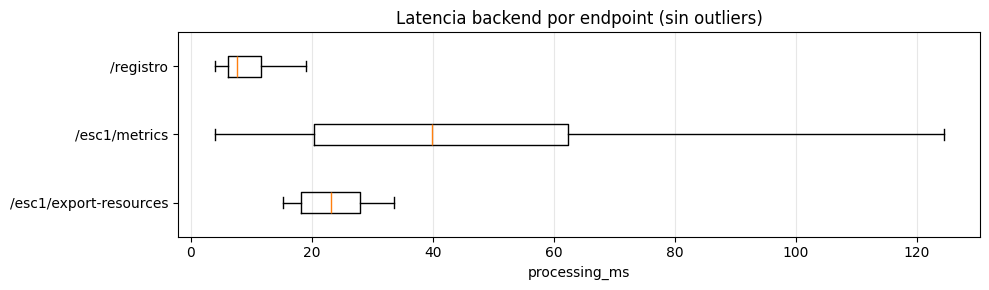

In [5]:
if not latency.empty:
    agg = latency.groupby('endpoint').agg(
        n=('processing_ms', 'count'),
        p50=('processing_ms', lambda x: np.percentile(x, 50)),
        p95=('processing_ms', lambda x: np.percentile(x, 95)),
        p99=('processing_ms', lambda x: np.percentile(x, 99)),
        max=('processing_ms', 'max'),
    ).round(1)
    agg['error_rate_pct'] = latency.groupby('endpoint').apply(
        lambda g: 100.0 * ((g['status_code'] >= 500) | (g['status_code'] == 0)).mean()).round(2)
    agg['availability_pct'] = (100 - agg['error_rate_pct']).round(2)
    print('TABLA 2 — Latencia backend por endpoint')
    display(agg)

    fig, ax = plt.subplots(figsize=(10, max(3, len(agg)*0.5)))
    data = [latency[latency['endpoint'] == ep]['processing_ms'].values for ep in agg.index]
    ax.boxplot(data, labels=list(agg.index), vert=False, showfliers=False)
    ax.set_xlabel('processing_ms'); ax.set_title('Latencia backend por endpoint (sin outliers)')
    ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()

## Tabla 3 + Gráfico 4 — Knee de concurrencia

TABLA 3 — Knee de concurrencia


,concurrency,requests,errors,rps,latency_p50_ms,latency_p95_ms,latency_p99_ms,error_rate_pct,degraded
0,5,1232,0,122.88,36.5,61.0,94.6,0.0,0
1,15,1448,0,143.75,96.9,155.6,172.6,0.0,0
2,30,1620,0,159.95,173.3,268.7,303.3,0.0,0



No se alcanzó degradación dentro del rango ensayado (máx 30)


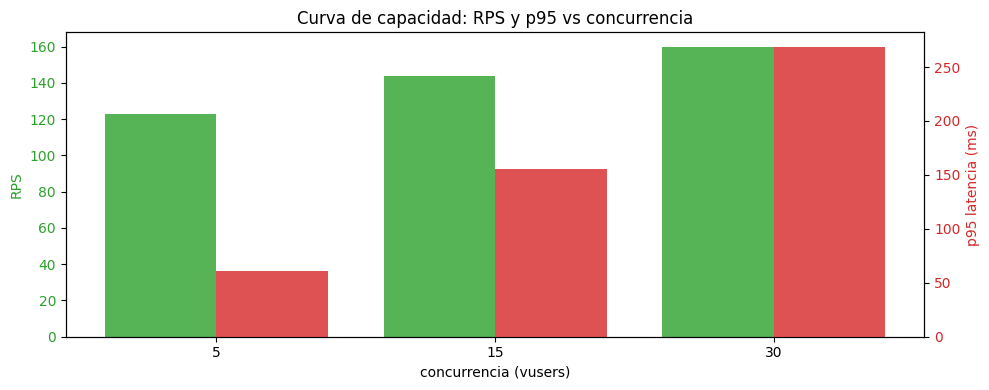

In [6]:
if not loadtest.empty:
    lt = loadtest.copy()
    lt['error_rate_pct'] = (lt['errors'] / lt['requests'].replace(0, 1) * 100).round(2)
    lt['degraded'] = ((lt['error_rate_pct'] > 1) | (lt['latency_p95_ms'] > 1000)).astype(int)
    print('TABLA 3 — Knee de concurrencia')
    display(lt[['concurrency','requests','errors','rps','latency_p50_ms','latency_p95_ms','latency_p99_ms','error_rate_pct','degraded']])
    deg = lt[lt['degraded'] == 1]
    if not deg.empty:
        knee = int(deg.iloc[0]['concurrency'])
        print(f'\nCAPACIDAD MÁXIMA FUNCIONAL: <{knee} concurrentes (primer escalón degradado)')
    else:
        print(f'\nNo se alcanzó degradación dentro del rango ensayado (máx {lt["concurrency"].max()})')

    fig, ax1 = plt.subplots(figsize=(10, 4))
    x = np.arange(len(lt))
    ax1.bar(x - 0.2, lt['rps'], width=0.4, label='RPS', color='tab:green', alpha=0.8)
    ax1.set_ylabel('RPS', color='tab:green'); ax1.tick_params(axis='y', labelcolor='tab:green')
    ax1.set_xticks(x); ax1.set_xticklabels(lt['concurrency'].astype(int))
    ax1.set_xlabel('concurrencia (vusers)')
    ax2 = ax1.twinx()
    ax2.bar(x + 0.2, lt['latency_p95_ms'], width=0.4, label='p95 latencia ms', color='tab:red', alpha=0.8)
    ax2.set_ylabel('p95 latencia (ms)', color='tab:red'); ax2.tick_params(axis='y', labelcolor='tab:red')
    if not deg.empty:
        ax1.axvline(deg.index[0], color='k', linestyle='--', alpha=0.4, label='knee')
    ax1.set_title('Curva de capacidad: RPS y p95 vs concurrencia')
    plt.tight_layout(); plt.show()

## Tabla 4 — Tiempo de montaje y plug-and-play

In [7]:
if not events.empty:
    ev = events.set_index('event')['ts']
    boot = ev.get('pi_boot')
    demo_start = ev.get('demo_start')
    first_user = ev.get('first_user')
    rows = []
    if boot and demo_start: rows.append(('pi_boot → demo_start', demo_start - boot))
    if demo_start and first_user: rows.append(('demo_start → first_user', first_user - demo_start))
    if boot and first_user: rows.append(('TOTAL montaje (pi_boot → first_user)', first_user - boot))
    if rows:
        df4 = pd.DataFrame(rows, columns=['fase', 'segundos'])
        df4['minutos'] = (df4['segundos'] / 60).round(2)
        print('TABLA 4 — Tiempo de montaje')
        display(df4)
    else:
        print('Faltan eventos pi_boot / demo_start / first_user en events.csv')

Faltan eventos pi_boot / demo_start / first_user en events.csv


## Tabla 5 + Gráfico 5 — SUS reducido + cualitativas

In [8]:
# SUS scoring: positive items (resp-1), negative items (5-resp). Sum, scale to 0-100.
SUS_POSITIVE = {'sus1', 'sus3', 'sus4', 'sus5'}
SUS_NEGATIVE = {'sus2', 'sus6'}

def sus_score(row):
    items = SUS_POSITIVE | SUS_NEGATIVE
    s = 0
    n = 0
    for it in items:
        if it in row and pd.notna(row[it]):
            v = int(row[it])
            s += (v - 1) if it in SUS_POSITIVE else (5 - v)
            n += 1
    return (s / (n * 4)) * 100 if n > 0 else np.nan

if not survey.empty:
    survey['sus_score'] = survey.apply(sus_score, axis=1)
    print(f'TABLA 5 — Satisfacción de la audiencia (n={len(survey)})')
    row5 = {
        'n_respondientes': len(survey),
        'SUS_score_promedio': round(survey['sus_score'].mean(), 1),
        'SUS_score_p50': round(survey['sus_score'].median(), 1),
    }
    for col in ('ped1', 'ped2'):
        if col in survey.columns:
            row5[f'{col}_promedio'] = round(pd.to_numeric(survey[col], errors='coerce').mean(), 2)
    display(pd.DataFrame([row5]).T.rename(columns={0: 'valor'}))

    sus_items = [c for c in survey.columns if c.startswith('sus')]
    if sus_items:
        fig, axes = plt.subplots(1, len(sus_items), figsize=(2*len(sus_items), 3), sharey=True)
        if len(sus_items) == 1: axes = [axes]
        for ax, item in zip(axes, sus_items):
            vals = pd.to_numeric(survey[item], errors='coerce').dropna().astype(int)
            counts = vals.value_counts().sort_index().reindex(range(1, 6), fill_value=0)
            ax.bar(counts.index.astype(str), counts.values)
            ax.set_title(item, fontsize=9); ax.set_xlabel('1..5')
        axes[0].set_ylabel('respondientes')
        plt.tight_layout(); plt.show()

## Reporte final (markdown) — copia y pega en el capítulo de Resultados

In [9]:
lines = [f'# Informe de desempeño — {SESSION_DIR.name}', '']
if not resources.empty:
    host = resources[resources['source'] == 'host']
    lines += [f'- CPU host promedio: {host["cpu_pct"].mean():.1f}% (max {host["cpu_pct"].max():.1f}%)',
              f'- RAM host promedio: {host["mem_mb"].mean():.0f} MB (max {host["mem_mb"].max():.0f} MB)']
if not router.empty:
    lines.append(f'- Teléfonos asociados máximos: {int(router["associated_stations"].max())}')
if not latency.empty:
    lines.append(f'- Latencia backend p95 global: {np.percentile(latency["processing_ms"], 95):.1f} ms')
if not loadtest.empty:
    deg = loadtest[((loadtest['errors']/loadtest['requests'].replace(0,1)*100) > 1) | (loadtest['latency_p95_ms'] > 1000)]
    if not deg.empty:
        lines.append(f'- Knee de concurrencia sintética: <{int(deg.iloc[0]["concurrency"])}')
if not events.empty:
    ev = events.set_index('event')['ts']
    boot, first_user = ev.get('pi_boot'), ev.get('first_user')
    if boot and first_user:
        lines.append(f'- Tiempo de montaje (boot→first_user): {(first_user-boot)/60:.1f} min')
if not survey.empty and 'sus_score' in survey.columns:
    lines.append(f'- SUS score promedio: {survey["sus_score"].mean():.1f} (n={len(survey)})')
report = '\n'.join(lines)
print(report)
(SESSION_DIR / f'report_{SESSION_DIR.name}.md').write_text(report)
print(f'\nGuardado en {SESSION_DIR}/report_{SESSION_DIR.name}.md')

# Informe de desempeño — esc1_2026-05-17_1848_validation

- CPU host promedio: 7.3% (max 16.1%)
- RAM host promedio: 311 MB (max 321 MB)
- Latencia backend p95 global: 99.3 ms

Guardado en sessions/esc1_2026-05-17_1848_validation/report_esc1_2026-05-17_1848_validation.md
